🎓 Student Admissions Data Analysis Pipeline
✅ Successfully loaded data from _admit.csv
📊 Dataset Overview:
Shape: (100000, 12)
Columns: ['Student ID', 'First Name', 'Last Name', 'GPA', 'SAT Score', 'Extracurricular Activities', 'Recommendation Letters', 'Application Type', 'Deposit Paid', 'Application Fee', 'Interview Feedback', 'Admission Decision']

First few rows:
                             Student ID First Name   Last Name   GPA  \
0  bd8be58c-513e-4563-8023-346be8840360    William        Hill  1.46   
1  40976e2b-2866-4b93-a9df-0f525804db7c    Valerie     Herrera  0.30   
2  ced66ce1-950b-4b1c-a1c4-d55accff86a2     Nicole  Pennington  3.33   
3  fd0b27b0-87c5-45ef-8f0d-7ee0215339fb    Matthew    Mitchell  0.24   
4  02bffed8-b27d-4bc1-9ed0-75f1c0bdd2dd    Zachary    Crawford  1.97   

   SAT Score  Extracurricular Activities  Recommendation Letters  \
0       1423                           9                       0   
1       1248                           3                     

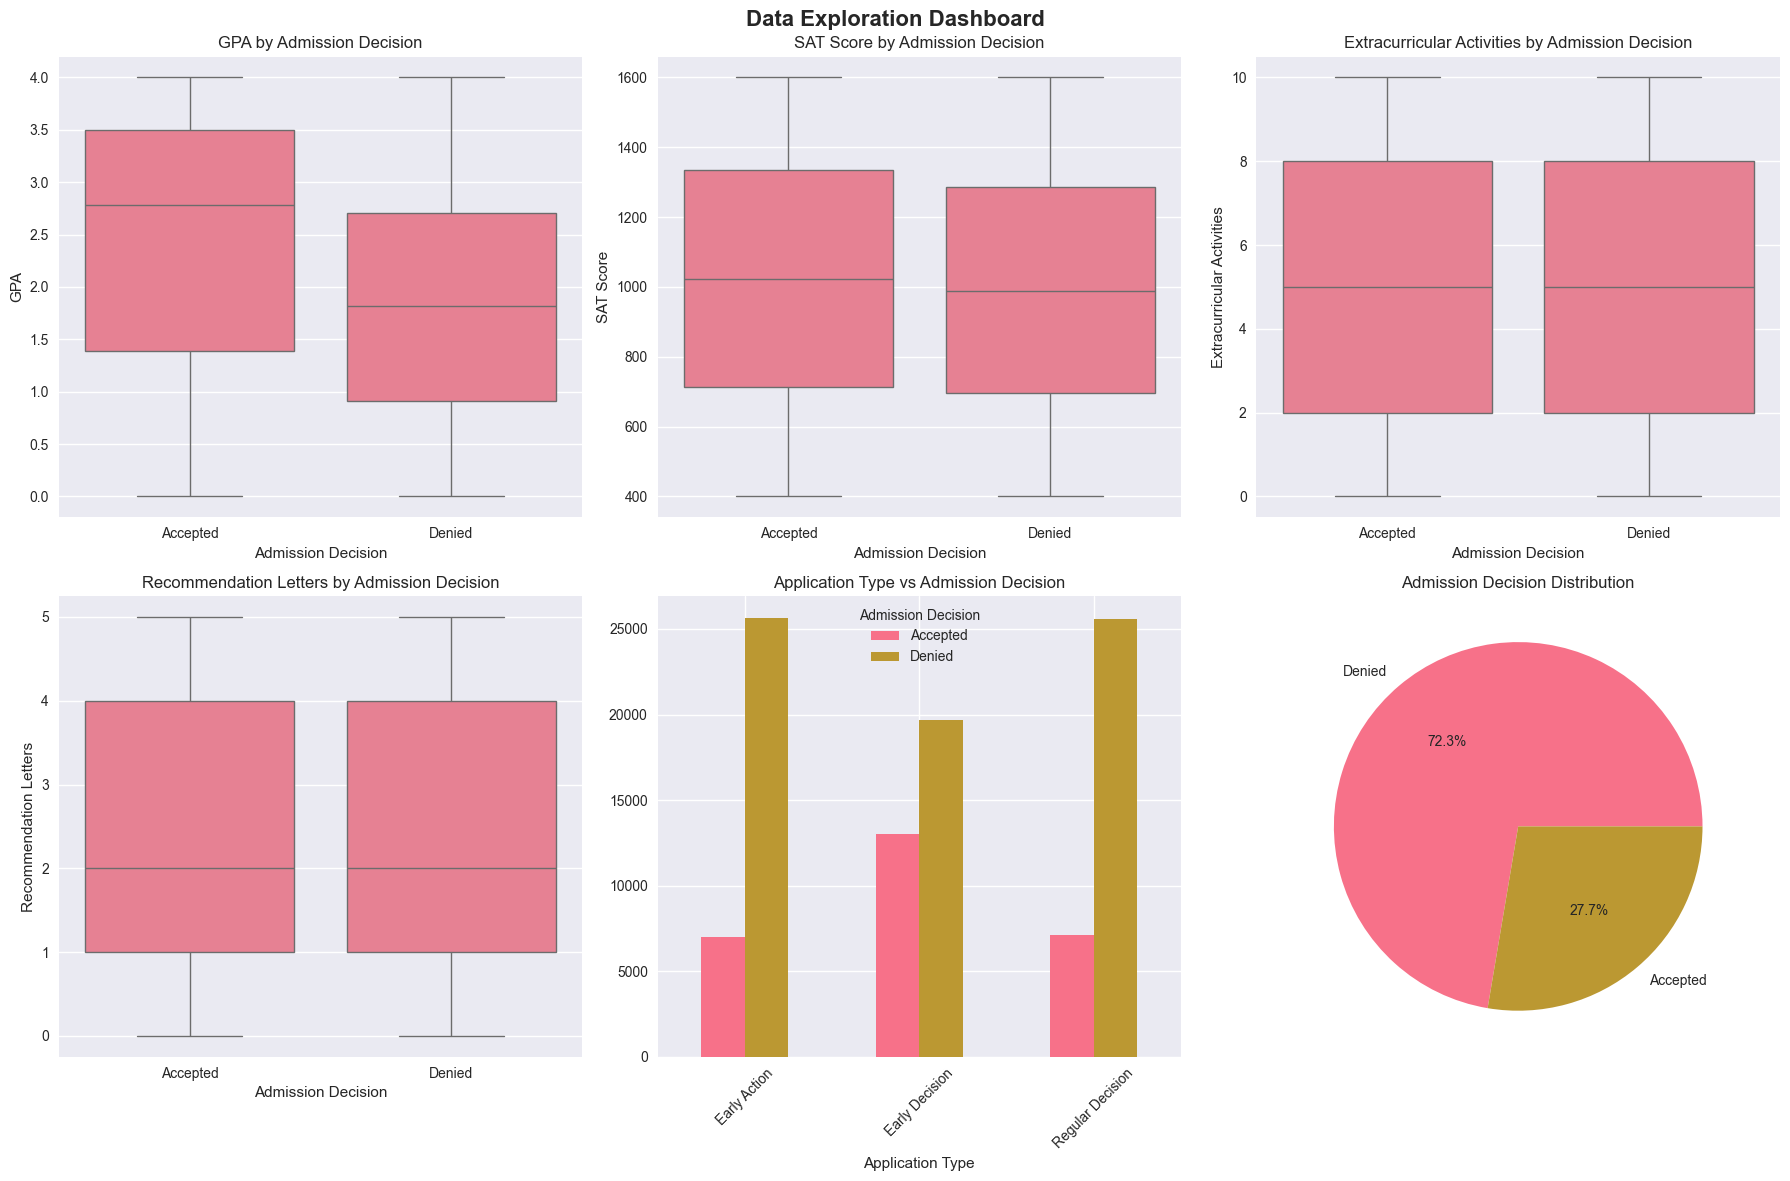


📈 Correlation Analysis
-------------------------
Correlations with target variable:
Recommendation Letters        0.003442
Extracurricular Activities   -0.002733
SAT Score                    -0.029578
Application Fee              -0.090955
GPA                          -0.228751
Interview Feedback           -0.511423
Name: Admission Decision_encoded, dtype: float64


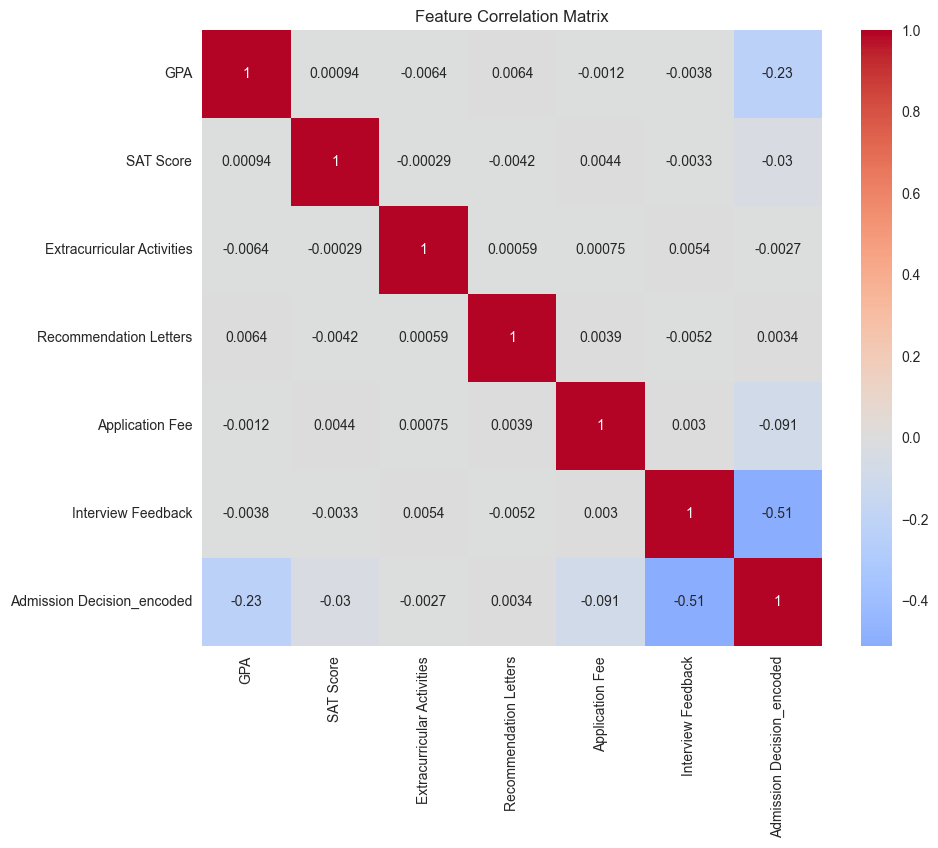


🚨 Data Leakage Risk Assessment
--------------------------------
  Student ID: NO RISK - Random identifier
  First Name: LOW RISK - Could introduce bias
  Last Name: LOW RISK - Could introduce bias
  GPA: NO RISK - Available before decision
  SAT Score: NO RISK - Available before decision
  Extracurricular Activities: NO RISK - Available before decision
  Recommendation Letters: NO RISK - Available before decision
  Application Type: NO RISK - Chosen before decision
  Deposit Paid: HIGH RISK - Usually paid after admission decision
  Application Fee: LOW RISK - Paid before decision
  Interview Feedback: MEDIUM RISK - Timing relative to decision unclear

✅ Selected 6 safe features (excluding 4 identifiers):
Excluded identifiers: ['Student ID', 'First Name', 'Last Name', 'Deposit Paid']
Safe features: ['GPA', 'SAT Score', 'Extracurricular Activities', 'Recommendation Letters', 'Application Type', 'Application Fee']

🤖 Training and Evaluating Models
-----------------------------------
Usin

In [ ]:
# Student Admissions Data Analysis Pipeline - Fixed
# Modular functions for reusable analysis across datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_and_inspect_data(filepath):
    """
    Load data and perform initial inspection
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Loaded dataframe
        dict: Basic info about the dataset
    """
    df = pd.read_csv(filepath)
    print(f"✅ Successfully loaded data from {filepath}")
    
    info = {
        'shape': df.shape,
        'columns': list(df.columns),
        'dtypes': df.dtypes.to_dict(),
        'memory_usage': df.memory_usage(deep=True).sum()
    }
    
    print("📊 Dataset Overview:")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print("\nFirst few rows:")
    print(df.head())
    
    return df, info

def auto_detect_column_types(df):
    """
    Automatically detect numerical, categorical, and identifier columns
    
    Args:
        df (pd.DataFrame): Input dataframe
        
    Returns:
        dict: Dictionary with column types
    """
    print(f"\n🔍 Auto-detecting Column Types")
    print("-" * 30)
    
    numerical_cols = []
    categorical_cols = []
    identifier_cols = []
    
    for col in df.columns:
        # Skip obvious identifiers and names - normalize spaces and case
        col_normalized = col.lower().replace(' ', '').replace('_', '')
        if any(keyword in col_normalized for keyword in ['id', 'firstname', 'lastname', 'name']):
            identifier_cols.append(col)
        # Numerical columns
        elif df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
        # Categorical columns (strings with reasonable number of unique values)
        elif df[col].dtype == 'object':
            unique_count = df[col].nunique()
            if unique_count <= 20:  # Reasonable threshold for categories
                categorical_cols.append(col)
            else:
                identifier_cols.append(col)  # Too many unique values, likely an identifier
    
    column_types = {
        'numerical': numerical_cols,
        'categorical': categorical_cols,
        'identifiers': identifier_cols
    }
    
    print("Detected column types:")
    print(f"Numerical: {numerical_cols}")
    print(f"Categorical: {categorical_cols}")
    print(f"Identifiers: {identifier_cols}")
    
    return column_types

def assess_data_quality(df, numerical_cols=None, categorical_cols=None):
    """
    Assess data quality issues and anomalies
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical column names
        categorical_cols (list): List of categorical column names
        
    Returns:
        dict: Data quality assessment results
    """
    print(f"\n📋 Data Quality Assessment")
    print("-" * 30)
    
    # Basic checks
    duplicates = df.duplicated().sum()
    missing_values = df.isnull().sum()
    
    print(f"Duplicate rows: {duplicates}")
    if missing_values.sum() > 0:
        print(f"Missing values per column:")
        print(missing_values[missing_values > 0])
    else:
        print("No missing values found ✅")
    
    quality_issues = {
        'duplicates': duplicates,
        'missing_values': missing_values.to_dict(),
        'anomalies': {}
    }
    
    # Domain-specific anomaly checks for admissions data
    if 'GPA' in df.columns:
        gpa_high = (df['GPA'] > 4.0).sum()
        gpa_low = (df['GPA'] < 0.0).sum()
        quality_issues['anomalies']['GPA_out_of_range'] = gpa_high + gpa_low
        if gpa_high > 0:
            print(f"GPA > 4.0: {gpa_high} records")
        if gpa_low > 0:
            print(f"GPA < 0.0: {gpa_low} records")
    
    if 'SAT Score' in df.columns:
        sat_out_of_range = ((df['SAT Score'] < 400) | (df['SAT Score'] > 1600)).sum()
        quality_issues['anomalies']['SAT_out_of_range'] = sat_out_of_range
        if sat_out_of_range > 0:
            print(f"SAT Score outside 400-1600 range: {sat_out_of_range} records")
    
    if 'Extracurricular Activities' in df.columns:
        negative_activities = (df['Extracurricular Activities'] < 0).sum()
        quality_issues['anomalies']['negative_activities'] = negative_activities
        if negative_activities > 0:
            print(f"Negative extracurricular activities: {negative_activities} records")
    
    return quality_issues

def analyze_target_distribution(df, target_col):
    """
    Analyze the distribution of the target variable
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Target distribution statistics
    """
    print(f"\n🎯 Target Variable Analysis: {target_col}")
    print("-" * 35)
    
    target_counts = df[target_col].value_counts()
    print(f"Distribution:")
    print(target_counts)
    
    # Calculate acceptance rate for admissions data
    if 'Accepted' in target_counts.index:
        acceptance_rate = target_counts['Accepted'] / len(df) * 100
        print(f"Acceptance Rate: {acceptance_rate:.1f}%")
        
        return {
            'counts': target_counts.to_dict(),
            'acceptance_rate': acceptance_rate
        }
    
    return {'counts': target_counts.to_dict()}

def create_exploratory_visualizations(df, target_col, numerical_cols, categorical_cols):
    """
    Create comprehensive exploratory visualizations
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        numerical_cols (list): List of numerical columns
        categorical_cols (list): List of categorical columns
    """
    print(f"\n🔍 Creating Exploratory Visualizations")
    print("-" * 40)
    
    # Calculate subplot dimensions
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Data Exploration Dashboard', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    plot_idx = 0
    
    # Numerical features vs target
    for col in numerical_cols[:4]:  # Limit to first 4 numerical columns
        if plot_idx < 6 and col in df.columns:
            sns.boxplot(data=df, x=target_col, y=col, ax=axes[plot_idx])
            axes[plot_idx].set_title(f'{col} by {target_col}')
            plot_idx += 1
    
    # Categorical features
    for col in categorical_cols[:2]:  # Limit to first 2 categorical columns
        if plot_idx < 6 and col in df.columns:
            unique_count = df[col].nunique()
            if unique_count <= 10:  # Only plot if reasonable number of categories
                if plot_idx == len(axes) - 1:  # Use pie chart for last plot
                    counts = df[col].value_counts()
                    axes[plot_idx].pie(counts.values, labels=counts.index, autopct='%1.1f%%')
                    axes[plot_idx].set_title(f'{col} Distribution')
                else:
                    pd.crosstab(df[col], df[target_col]).plot(kind='bar', ax=axes[plot_idx])
                    axes[plot_idx].set_title(f'{col} vs {target_col}')
                    axes[plot_idx].tick_params(axis='x', rotation=45)
                plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_feature_correlations(df, numerical_cols, target_col):
    """
    Analyze correlations between features and target
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical columns
        target_col (str): Name of target column
        
    Returns:
        pd.Series: Correlations with target variable
    """
    print(f"\n📈 Correlation Analysis")
    print("-" * 25)
    
    # Encode target if categorical
    df_corr = df.copy()
    if df[target_col].dtype == 'object':
        le = LabelEncoder()
        df_corr[f'{target_col}_encoded'] = le.fit_transform(df[target_col])
        target_encoded = f'{target_col}_encoded'
    else:
        target_encoded = target_col
    
    # Calculate correlations
    correlation_cols = [col for col in numerical_cols if col in df.columns]
    correlation_cols.append(target_encoded)
    
    corr_matrix = df_corr[correlation_cols].corr()
    corr_with_target = corr_matrix[target_encoded].drop(target_encoded).sort_values(ascending=False)
    
    print("Correlations with target variable:")
    print(corr_with_target)
    
    # Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.show()
    
    return corr_with_target

def assess_data_leakage_risk(df, target_col):
    """
    Assess potential data leakage risks
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Leakage risk assessment
    """
    print(f"\n🚨 Data Leakage Risk Assessment")
    print("-" * 32)
    
    # Define leakage risk rules (can be customized for different domains)
    leakage_rules = {
        'Deposit Paid': 'HIGH RISK - Usually paid after admission decision',
        'Application Fee': 'LOW RISK - Paid before decision',
        'Interview Feedback': 'MEDIUM RISK - Timing relative to decision unclear',
        'Student ID': 'NO RISK - Random identifier',
        'First Name': 'LOW RISK - Could introduce bias',
        'Last Name': 'LOW RISK - Could introduce bias',
        'GPA': 'NO RISK - Available before decision',
        'SAT Score': 'NO RISK - Available before decision',
        'Extracurricular Activities': 'NO RISK - Available before decision',
        'Recommendation Letters': 'NO RISK - Available before decision',
        'Application Type': 'NO RISK - Chosen before decision'
    }
    
    assessment = {}
    for col in df.columns:
        if col != target_col:
            risk_level = leakage_rules.get(col, 'UNKNOWN RISK - Manual review needed')
            assessment[col] = risk_level
            print(f"  {col}: {risk_level}")
    
    # Specific checks for admissions data
    if 'Deposit Paid' in df.columns and target_col == 'Admission Decision':
        denied_with_deposit = df[(df[target_col] == 'Denied') & (df['Deposit Paid'] > 0)]
        if len(denied_with_deposit) > 0:
            print(f"\n⚠️ CRITICAL: {len(denied_with_deposit)} denied students with deposits - potential leakage!")
            assessment['critical_leakage_detected'] = True
        else:
            assessment['critical_leakage_detected'] = False
    
    return assessment

def select_safe_features(df, leakage_assessment, column_types):
    """
    Select features that are safe to use (low leakage risk and not identifiers)
    
    Args:
        df (pd.DataFrame): Input dataframe
        leakage_assessment (dict): Output from assess_data_leakage_risk
        column_types (dict): Output from auto_detect_column_types
        
    Returns:
        list: List of safe feature names
    """
    safe_features = []
    
    # Get identifier columns to exclude
    identifier_cols = column_types.get('identifiers', [])
    
    for feature, risk in leakage_assessment.items():
        if feature != 'critical_leakage_detected':
            if 'NO RISK' in risk or 'LOW RISK' in risk:
                if feature in df.columns and feature not in identifier_cols:
                    safe_features.append(feature)
    
    print(f"\n✅ Selected {len(safe_features)} safe features (excluding {len(identifier_cols)} identifiers):")
    print(f"Excluded identifiers: {identifier_cols}")
    print(f"Safe features: {safe_features}")
    
    return safe_features

def make_classification_pipeline():
    """
    Create a classification pipeline with preprocessing
    
    Returns:
        Pipeline: Scikit-learn pipeline for classification
    """
    # Numerical preprocessing
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical preprocessing
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    # Combined preprocessor
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, lambda X: X.select_dtypes(include=[np.number]).columns.tolist()),
        ('cat', cat_pipeline, lambda X: X.select_dtypes(include=['object']).columns.tolist())
    ])
    
    # Complete pipeline with XGBoost
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=100, 
            random_state=42, 
            eval_metric='logloss',
            verbosity=0
        ))
    ])
    
    return pipeline

def tune_hyperparameters(X_train, y_train):
    """
    Perform hyperparameter tuning on XGBoost using GridSearchCV with 5-fold cross-validation
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (array-like): Training target
        
    Returns:
        tuple: (best_pipeline, best_params, cv_results)
    """
    print(f"\n🔧 Hyperparameter Tuning for XGBoost")
    print("-" * 35)
    
    # Create base pipeline
    base_pipeline = make_classification_pipeline()
    
    # Define parameter grid for XGBoost
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 6, 9],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
    
    # Perform grid search with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    print("Starting hyperparameter tuning...")
    print(f"Testing {len(param_grid['classifier__n_estimators']) * len(param_grid['classifier__max_depth']) * len(param_grid['classifier__learning_rate']) * len(param_grid['classifier__subsample']) * len(param_grid['classifier__colsample_bytree'])} parameter combinations")
    
    grid_search.fit(X_train, y_train)
    
    print(f"✅ Hyperparameter tuning complete!")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.cv_results_

def train_and_evaluate_models(df, feature_cols, target_col, tune_hyperparams=False):
    """
    Train and evaluate multiple classification models
    
    Args:
        df (pd.DataFrame): Input dataframe
        feature_cols (list): List of feature column names
        target_col (str): Name of target column
        tune_hyperparams (bool): Whether to perform hyperparameter tuning on XGBoost
        
    Returns:
        dict: Model results and metrics
    """
    print(f"\n🤖 Training and Evaluating Models")
    print("-" * 35)
    
    # Prepare data
    X = df[feature_cols].copy()
    
    # Clean target variable - remove any NaN values
    target_data = df[target_col].dropna()
    valid_indices = target_data.index
    X = X.loc[valid_indices]
    
    # Encode target if needed
    if target_data.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(target_data)
        target_classes = le.classes_.tolist()
        # Ensure target_classes are all strings for classification_report
        target_classes = [str(cls) for cls in target_classes]
    else:
        y = target_data.values
        target_classes = None
    
    print(f"Using {len(X)} samples after cleaning")
    print(f"Target classes: {target_classes}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Define models
    models = {
        'Logistic Regression': Pipeline([
            ('preprocessor', make_classification_pipeline().named_steps['preprocessor']),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ])
    }
    
    # Add XGBoost model (tuned or default)
    if tune_hyperparams:
        print("Training XGBoost with hyperparameter tuning...")
        tuned_xgb, best_params, cv_results = tune_hyperparameters(X_train, y_train)
        models['XGBoost (Tuned)'] = tuned_xgb
    else:
        models['XGBoost'] = make_classification_pipeline()
    
    results = {}
    
    for name, pipeline in models.items():
        print(f"\nTraining {name}...")
        
        # Skip fitting for tuned XGBoost as it's already fitted
        if name == 'XGBoost (Tuned)':
            # Pipeline is already fitted from hyperparameter tuning
            pass
        else:
            # Train model
            pipeline.fit(X_train, y_train)
        
        # Predictions
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if len(np.unique(y)) == 2 else None
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
        
        results[name] = {
            'pipeline': pipeline,
            'accuracy': accuracy,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"Accuracy: {accuracy:.3f}")
        if auc_score:
            print(f"AUC Score: {auc_score:.3f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=target_classes))
    
    return results

def extract_feature_importance(model_results, feature_cols):
    """
    Extract and display feature importance from trained models
    
    Args:
        model_results (dict): Results from train_and_evaluate_models
        feature_cols (list): List of feature column names
        
    Returns:
        pd.DataFrame: Feature importance scores
    """
    print(f"\n🎯 Feature Importance Analysis")
    print("-" * 30)
    
    # Get XGBoost model (tuned or default)
    target_pipeline = None
    for name, results in model_results.items():
        if 'XGBoost' in name:
            target_pipeline = results['pipeline']
            break
    
    if target_pipeline is None:
        print("No XGBoost model found for feature importance extraction")
        return None
    
    # Extract feature names after preprocessing
    preprocessor = target_pipeline.named_steps['preprocessor']
    classifier = target_pipeline.named_steps['classifier']
    
    # Get feature names (this is tricky with ColumnTransformer)
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        # Fallback: use original feature names (not ideal but works)
        feature_names = feature_cols
    
    # Get importance scores
    if hasattr(classifier, 'feature_importances_'):
        importance_scores = classifier.feature_importances_
        
        # Create DataFrame
        n_features = min(len(feature_names), len(importance_scores))
        importance_df = pd.DataFrame({
            'feature': feature_names[:n_features],
            'importance': importance_scores[:n_features]
        }).sort_values('importance', ascending=False)
        
        print("Top feature importances:")
        print(importance_df.head(10))
        
        return importance_df
    
    return None

def calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment):
    """
    Calculate an overall pipeline readiness score
    
    Args:
        quality_issues (dict): Data quality assessment results
        model_results (dict): Model evaluation results
        leakage_assessment (dict): Leakage risk assessment
        
    Returns:
        dict: Readiness scores and overall assessment
    """
    print(f"\n💡 Pipeline Readiness Assessment")
    print("-" * 32)
    
    # Data quality score (0-100)
    quality_score = 100
    if quality_issues['duplicates'] > 0:
        quality_score -= 10
    
    missing_penalty = sum(1 for count in quality_issues['missing_values'].values() if count > 0)
    quality_score -= min(missing_penalty * 5, 30)
    
    anomaly_penalty = sum(quality_issues['anomalies'].values())
    quality_score -= min(anomaly_penalty, 30)
    
    quality_score = max(0, quality_score)
    
    # Model performance score (0-100)
    if model_results:
        best_auc = max([r.get('auc_score', 0) or 0 for r in model_results.values()])
        best_accuracy = max([r.get('accuracy', 0) for r in model_results.values()])
        performance_score = max(best_auc, best_accuracy) * 100
    else:
        performance_score = 0
    
    # Leakage risk score (0-100)
    high_risk_count = sum(1 for risk in leakage_assessment.values() 
                         if isinstance(risk, str) and 'HIGH RISK' in risk)
    critical_leakage = leakage_assessment.get('critical_leakage_detected', False)
    
    leakage_score = 100 - (high_risk_count * 30)
    if critical_leakage:
        leakage_score -= 50
    leakage_score = max(0, leakage_score)
    
    # Overall score
    overall_score = (quality_score + performance_score + leakage_score) / 3
    
    scores = {
        'data_quality': quality_score,
        'model_performance': performance_score,
        'leakage_risk': leakage_score,
        'overall': overall_score
    }
    
    print(f"Data Quality Score: {quality_score:.1f}/100")
    print(f"Model Performance Score: {performance_score:.1f}/100")
    print(f"Leakage Risk Score: {leakage_score:.1f}/100")
    print(f"Overall Pipeline Readiness: {overall_score:.1f}/100")
    
    return scores

def generate_summary_findings(df, scores, model_results, feature_importance):
    """
    Generate summary findings for the analysis
    
    Args:
        df (pd.DataFrame): Input dataframe
        scores (dict): Pipeline readiness scores
        model_results (dict): Model evaluation results
        feature_importance (pd.DataFrame): Feature importance results
        
    Returns:
        list: Summary findings
    """
    findings = []
    
    findings.append(f"Dataset contains {len(df)} records with {len(df.columns)} features")
    
    if 'Admission Decision' in df.columns:
        acceptance_rate = (df['Admission Decision'] == 'Accepted').mean() * 100
        findings.append(f"Current acceptance rate: {acceptance_rate:.1f}%")
    
    findings.append(f"Overall pipeline readiness score: {scores['overall']:.1f}/100")
    
    if model_results:
        best_model = max(model_results.items(), key=lambda x: x[1].get('auc_score', 0) or x[1].get('accuracy', 0))
        best_score = best_model[1].get('auc_score') or best_model[1].get('accuracy')
        findings.append(f"Best model ({best_model[0]}) score: {best_score:.3f}")
    
    if feature_importance is not None and len(feature_importance) > 0:
        top_features = feature_importance.head(3)['feature'].tolist()
        findings.append(f"Top predictive features: {', '.join(top_features)}")
    
    return findings

def run_full_pipeline(filepath, target_col='Admission Decision', tune_hyperparams=False):
    """
    Run the complete analysis pipeline
    
    Args:
        filepath (str): Path to the CSV file
        target_col (str): Name of the target column
        tune_hyperparams (bool): Whether to perform hyperparameter tuning on XGBoost
        
    Returns:
        dict: Complete analysis results
    """
    print("🎓 Student Admissions Data Analysis Pipeline")
    print("=" * 50)
    
    # 1. Load and inspect data
    df, basic_info = load_and_inspect_data(filepath)
    
    # 2. Auto-detect column types
    column_types = auto_detect_column_types(df)
    
    # 3. Assess data quality
    quality_issues = assess_data_quality(df, column_types['numerical'], column_types['categorical'])
    
    # 4. Analyze target distribution
    target_stats = analyze_target_distribution(df, target_col)
    
    # 5. Create visualizations
    create_exploratory_visualizations(df, target_col, column_types['numerical'], column_types['categorical'])
    
    # 6. Analyze correlations
    correlations = analyze_feature_correlations(df, column_types['numerical'], target_col)
    
    # 7. Assess leakage risk
    leakage_assessment = assess_data_leakage_risk(df, target_col)
    
    # 8. Select safe features
    safe_features = select_safe_features(df, leakage_assessment, column_types)
    
    # 9. Train and evaluate models
    model_results = train_and_evaluate_models(df, safe_features, target_col, tune_hyperparams)
    
    # 10. Extract feature importance
    feature_importance = extract_feature_importance(model_results, safe_features)
    
    # 11. Calculate readiness scores
    scores = calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment)
    
    # 12. Generate summary
    findings = generate_summary_findings(df, scores, model_results, feature_importance)
    
    print(f"\n📝 Key Findings Summary")
    print("-" * 25)
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")
    
    print(f"\n✅ Pipeline analysis complete!")
    
    return {
        'dataframe': df,
        'basic_info': basic_info,
        'column_types': column_types,
        'quality_issues': quality_issues,
        'target_stats': target_stats,
        'correlations': correlations,
        'leakage_assessment': leakage_assessment,
        'safe_features': safe_features,
        'model_results': model_results,
        'feature_importance': feature_importance,
        'scores': scores,
        'findings': findings
    }

# Example usage:
if __name__ == "__main__":
    # Run the complete pipeline without hyperparameter tuning
    results = run_full_pipeline("_admit.csv")
    
    # Or run with hyperparameter tuning (takes longer)
    # results = run_full_pipeline("_admit.csv", tune_hyperparams=True)
    
    # Access specific results
    print(f"\nSafe features to use: {results['safe_features']}")
    print(f"Overall readiness score: {results['scores']['overall']:.1f}")